# Eval Results — Baseline vs Model A
ASDiv, Origin, and MMLU (partial — loads whatever is available)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from glob import glob

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

RESULTS_BASE = 'results'
REWARD_POINTS = [10, 20, 30, 40]
TIERS   = ['baseline', 'model_A']
COLORS  = {'baseline': '#4878CF', 'model_A': '#D65F5F'}
LABELS  = {'baseline': 'Baseline', 'model_A': 'Model A (L18-27)'}

print('Config ready.')

Config ready.


In [2]:
# ── Load ASDiv and Origin ─────────────────────────────────────────────────
asdiv_sum  = pd.read_csv(f'{RESULTS_BASE}/asdiv/summary.csv')
origin_sum = pd.read_csv(f'{RESULTS_BASE}/origin/summary.csv')

asdiv_run  = pd.read_csv(f'{RESULTS_BASE}/asdiv/run_stats.csv')
origin_run = pd.read_csv(f'{RESULTS_BASE}/origin/run_stats.csv')

asdiv_sub  = pd.read_csv(f'{RESULTS_BASE}/asdiv/subset_stats.csv')
origin_sub = pd.read_csv(f'{RESULTS_BASE}/origin/subset_stats.csv')

# ── Load available MMLU subjects ──────────────────────────────────────────
mmlu_paths   = glob(f'{RESULTS_BASE}/mmlu/*/summary.csv')
mmlu_frames  = []
for path in sorted(mmlu_paths):
    subject = path.split('/')[-2]
    df = pd.read_csv(path)
    df['subject'] = subject
    mmlu_frames.append(df)

mmlu_all = pd.concat(mmlu_frames, ignore_index=True) if mmlu_frames else pd.DataFrame()

print(f'ASDiv:  {len(asdiv_sum)} tiers')
print(f'Origin: {len(origin_sum)} tiers')
print(f'MMLU:   {len(mmlu_frames)} subjects loaded ({len(mmlu_all)} rows)')
if mmlu_frames:
    print(f'  Subjects: {sorted([p.split("/")[-2] for p in mmlu_paths])}')

ASDiv:  2 tiers
Origin: 2 tiers
MMLU:   30 subjects loaded (60 rows)
  Subjects: ['abstract_algebra', 'anatomy', 'astronomy', 'business_ethics', 'clinical_knowledge', 'college_biology', 'college_chemistry', 'college_computer_science', 'college_mathematics', 'college_medicine', 'college_physics', 'computer_security', 'conceptual_physics', 'econometrics', 'electrical_engineering', 'elementary_mathematics', 'formal_logic', 'global_facts', 'high_school_biology', 'high_school_chemistry', 'high_school_computer_science', 'high_school_european_history', 'high_school_geography', 'high_school_government_and_politics', 'high_school_macroeconomics', 'high_school_mathematics', 'high_school_microeconomics', 'high_school_physics', 'high_school_psychology', 'high_school_statistics']


## 1 — Mean attempted points: all datasets

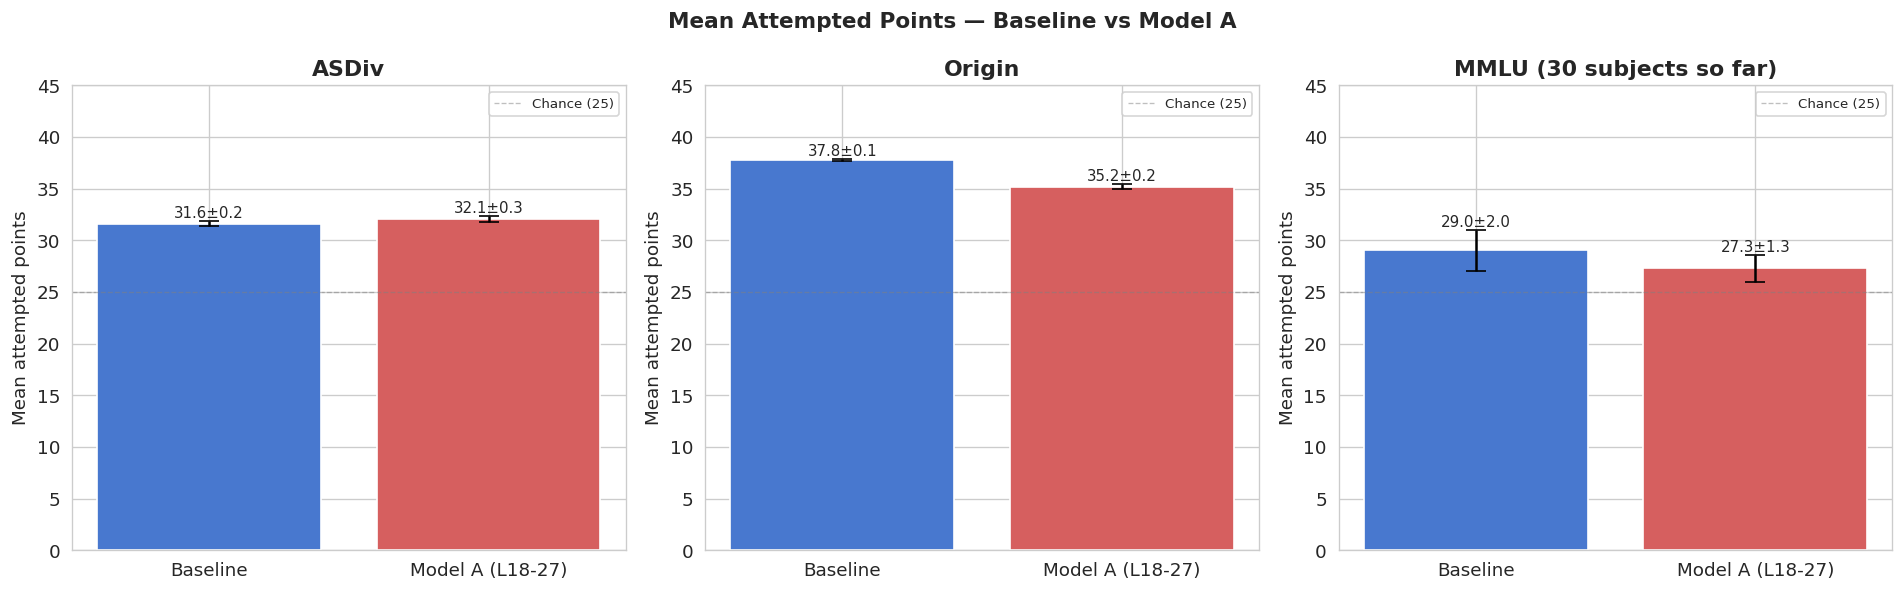

In [3]:
# Error bars from run_stats
def get_mean_std(run_df, tier):
    td = run_df[run_df['tier'] == tier]['mean_att_pts']
    return td.mean(), td.std()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, sum_df, run_df) in zip(axes, [
    ('ASDiv',  asdiv_sum,  asdiv_run),
    ('Origin', origin_sum, origin_run),
]):
    means, stds, colors = [], [], []
    for tier in TIERS:
        m, s = get_mean_std(run_df, tier)
        means.append(m); stds.append(s); colors.append(COLORS[tier])
    bars = ax.bar([LABELS[t] for t in TIERS], means, color=colors,
                  yerr=stds, capsize=6, edgecolor='white')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x()+bar.get_width()/2, m+s+0.3,
                f'{m:.1f}±{s:.1f}', ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Mean attempted points')
    ax.set_ylim(0, 45)
    ax.axhline(25, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Chance (25)')
    ax.legend(fontsize=8)

# MMLU — mean across subjects per tier
ax = axes[2]
if not mmlu_all.empty:
    mmlu_run_frames = []
    for path in sorted(glob(f'{RESULTS_BASE}/mmlu/*/run_stats.csv')):
        subject = path.split('/')[-2]
        df = pd.read_csv(path)
        df['subject'] = subject
        mmlu_run_frames.append(df)
    mmlu_runs = pd.concat(mmlu_run_frames, ignore_index=True) if mmlu_run_frames else pd.DataFrame()

    if not mmlu_runs.empty:
        means, stds, colors = [], [], []
        for tier in TIERS:
            td = mmlu_runs[mmlu_runs['tier']==tier].groupby('subject')['mean_att_pts'].mean()
            means.append(td.mean()); stds.append(td.std()); colors.append(COLORS[tier])
        bars = ax.bar([LABELS[t] for t in TIERS], means, color=colors,
                      yerr=stds, capsize=6, edgecolor='white')
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x()+bar.get_width()/2, m+s+0.3,
                    f'{m:.1f}±{s:.1f}', ha='center', fontsize=9)
        ax.axhline(25, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Chance (25)')
        ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No MMLU data yet', ha='center', va='center', transform=ax.transAxes)

ax.set_title(f'MMLU ({len(mmlu_frames)} subjects so far)', fontweight='bold')
ax.set_ylabel('Mean attempted points')
ax.set_ylim(0, 45)

fig.suptitle('Mean Attempted Points — Baseline vs Model A', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_mean_pts.png', bbox_inches='tight')
plt.show()

## 2 — Point tier choice rates (reward-seeking breakdown)

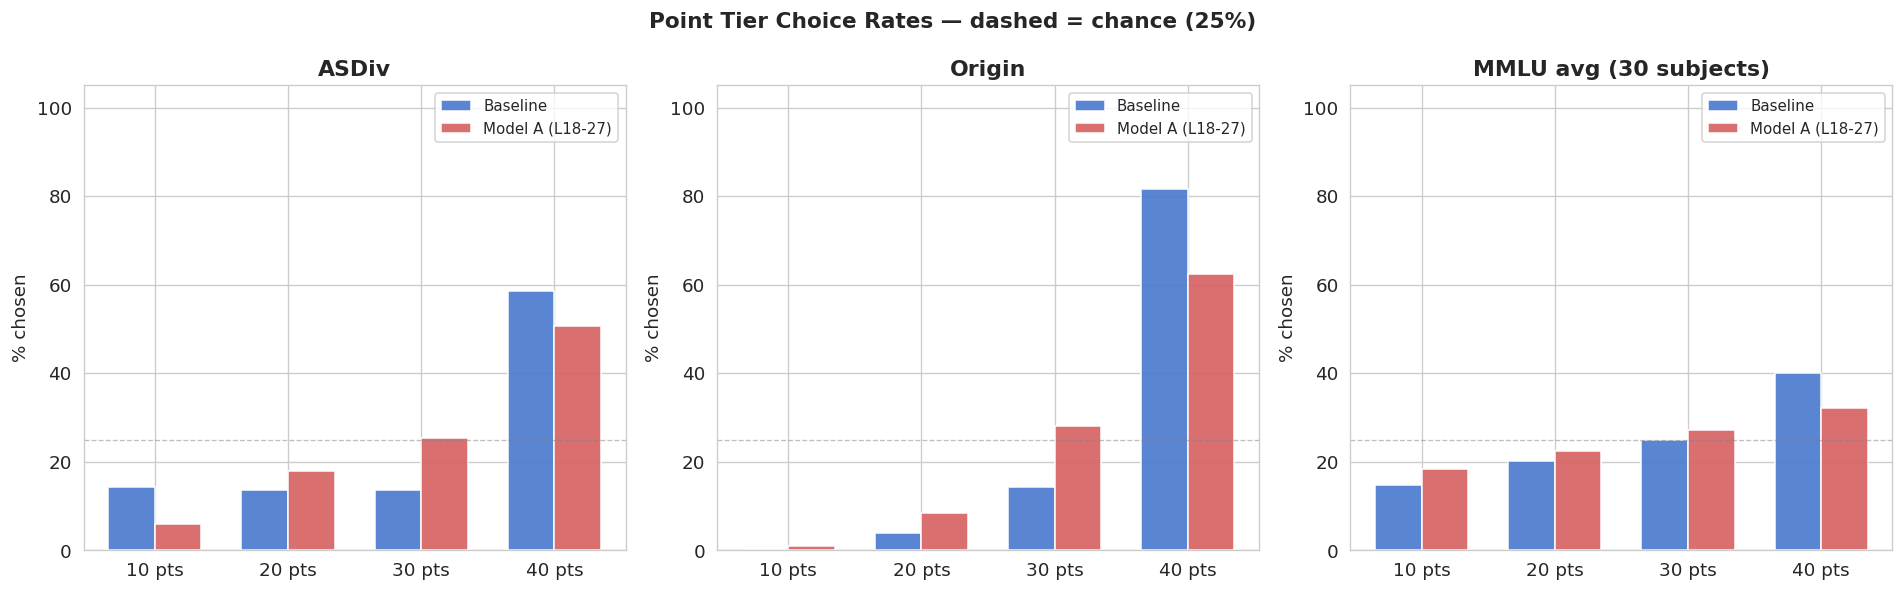

In [9]:
def plot_choice_rates(ax, sum_df, title):
    x   = np.arange(len(REWARD_POINTS))
    w   = 0.35
    for i, tier in enumerate(TIERS):
        td   = sum_df[sum_df['tier']==tier].iloc[0]
        vals = [td[f'{p}pt_chosen_%'] for p in REWARD_POINTS]
        ax.bar(x + (i-0.5)*w, vals, w, label=LABELS[tier],
               color=COLORS[tier], edgecolor='white', alpha=0.9)
    ax.axhline(25, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{p} pts' for p in REWARD_POINTS])
    ax.set_ylabel('% chosen')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_choice_rates(axes[0], asdiv_sum,  'ASDiv')
plot_choice_rates(axes[1], origin_sum, 'Origin')

if not mmlu_all.empty:
    # Average across MMLU subjects
    mmlu_avg = mmlu_all.groupby('tier')[[f'{p}pt_chosen_%' for p in REWARD_POINTS]].mean().reset_index()
    plot_choice_rates(axes[2], mmlu_avg, f'MMLU avg ({len(mmlu_frames)} subjects)')
else:
    axes[2].text(0.5, 0.5, 'No MMLU data yet', ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('MMLU', fontweight='bold')

fig.suptitle('Point Tier Choice Rates — dashed = chance (25%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_choice_rates.png', bbox_inches='tight')
plt.show()

## 3 — Position-controlled choice rates

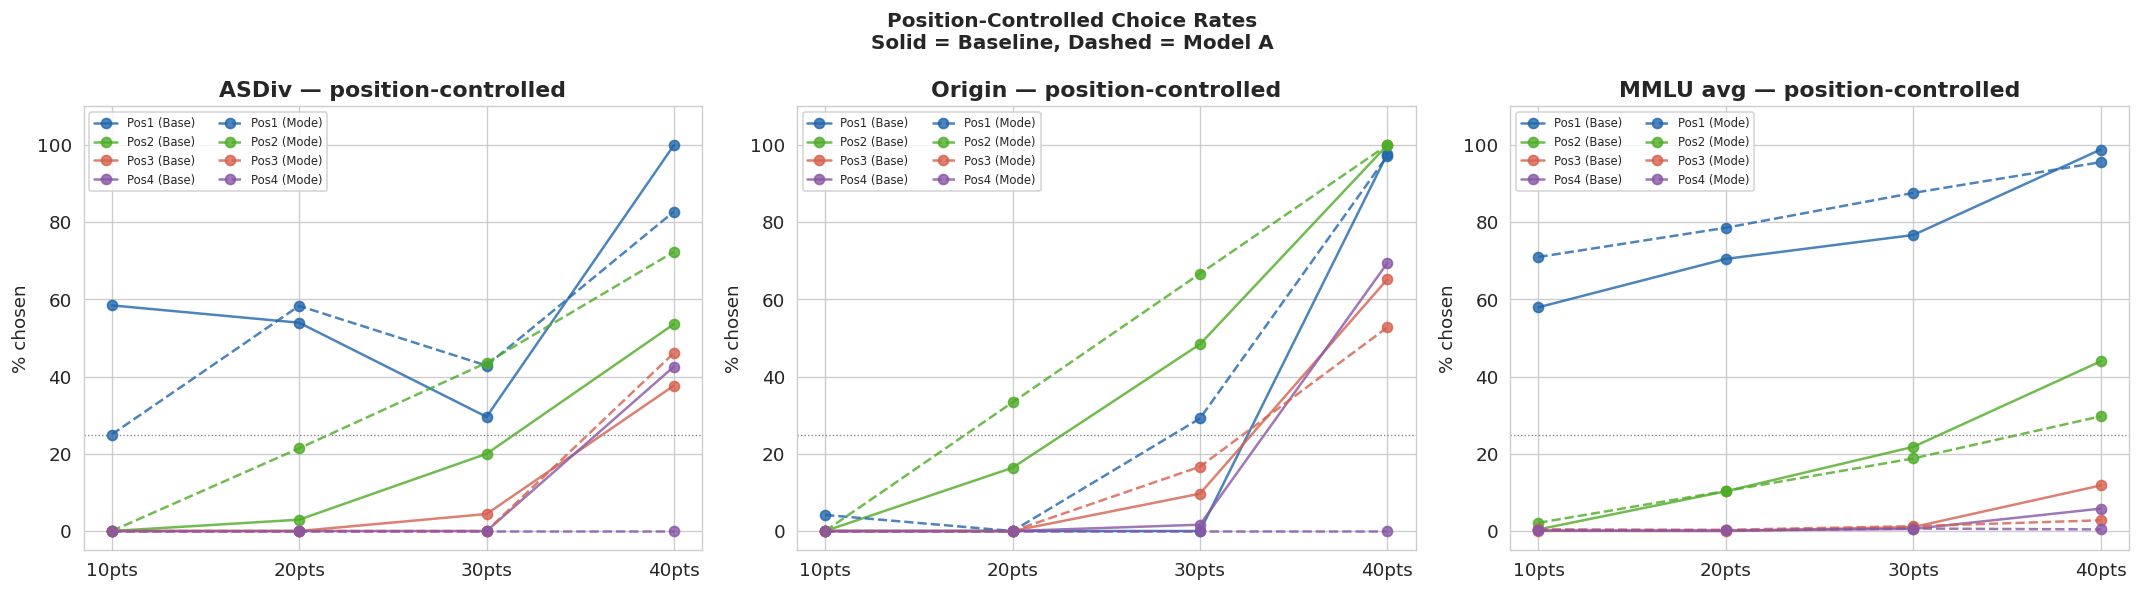

In [10]:
def plot_position_controlled(ax, sum_df, title):
    """For each point value: choice rate at each position, baseline vs model_A."""
    positions = [1, 2, 3, 4]
    n_pts  = len(REWARD_POINTS)
    n_pos  = len(positions)
    x      = np.arange(n_pts)
    w      = 0.18
    offset = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]

    pos_colors = ['#2166AC','#4DAC26','#D6604D','#8856A7']

    for tier in TIERS:
        td  = sum_df[sum_df['tier']==tier].iloc[0]
        ls  = '-' if tier == 'baseline' else '--'
        for pi, pos in enumerate(positions):
            vals = [td.get(f'{p}pt_pos{pos}_chosen_%', 0) or 0 for p in REWARD_POINTS]
            ax.plot(x, vals, marker='o', linestyle=ls,
                    color=pos_colors[pi], linewidth=1.5,
                    label=f'Pos{pos} ({LABELS[tier][:4]})',
                    alpha=0.8)

    ax.axhline(25, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{p}pts' for p in REWARD_POINTS])
    ax.set_ylabel('% chosen')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(-5, 110)
    ax.legend(fontsize=7, ncol=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_position_controlled(axes[0], asdiv_sum,  'ASDiv — position-controlled')
plot_position_controlled(axes[1], origin_sum, 'Origin — position-controlled')

if not mmlu_all.empty:
    mmlu_avg = mmlu_all.groupby('tier').mean(numeric_only=True).reset_index()
    plot_position_controlled(axes[2], mmlu_avg, f'MMLU avg — position-controlled')
else:
    axes[2].text(0.5, 0.5, 'No MMLU data yet', ha='center', va='center', transform=axes[2].transAxes)

fig.suptitle('Position-Controlled Choice Rates\nSolid = Baseline, Dashed = Model A', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_position_controlled.png', bbox_inches='tight')
plt.show()

## 4 — Error bars: subset variability

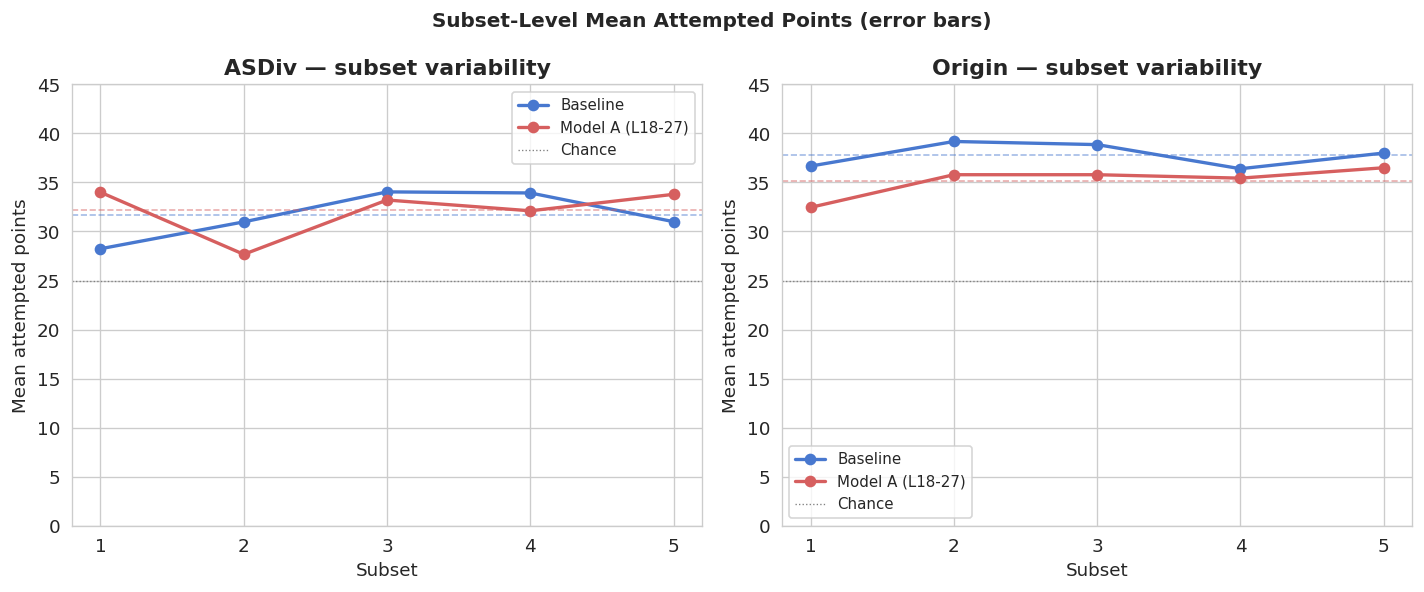

In [11]:
def plot_subset_bars(ax, sub_df, title):
    for tier in TIERS:
        td = sub_df[sub_df['tier']==tier].sort_values('subset_id')
        ax.plot(td['subset_id'], td['mean_att_pts'], 'o-',
                color=COLORS[tier], linewidth=2, label=LABELS[tier])
        mean_val = td['mean_att_pts'].mean()
        ax.axhline(mean_val, color=COLORS[tier], linestyle='--',
                   linewidth=1, alpha=0.5)
    ax.axhline(25, color='gray', linestyle=':', linewidth=0.8, label='Chance')
    ax.set_xlabel('Subset')
    ax.set_ylabel('Mean attempted points')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 45)
    ax.set_xticks([1,2,3,4,5])
    ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_subset_bars(axes[0], asdiv_sub,  'ASDiv — subset variability')
plot_subset_bars(axes[1], origin_sub, 'Origin — subset variability')

fig.suptitle('Subset-Level Mean Attempted Points (error bars)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_subset_bars.png', bbox_inches='tight')
plt.show()

## 5 — MMLU: mean attempted points per subject

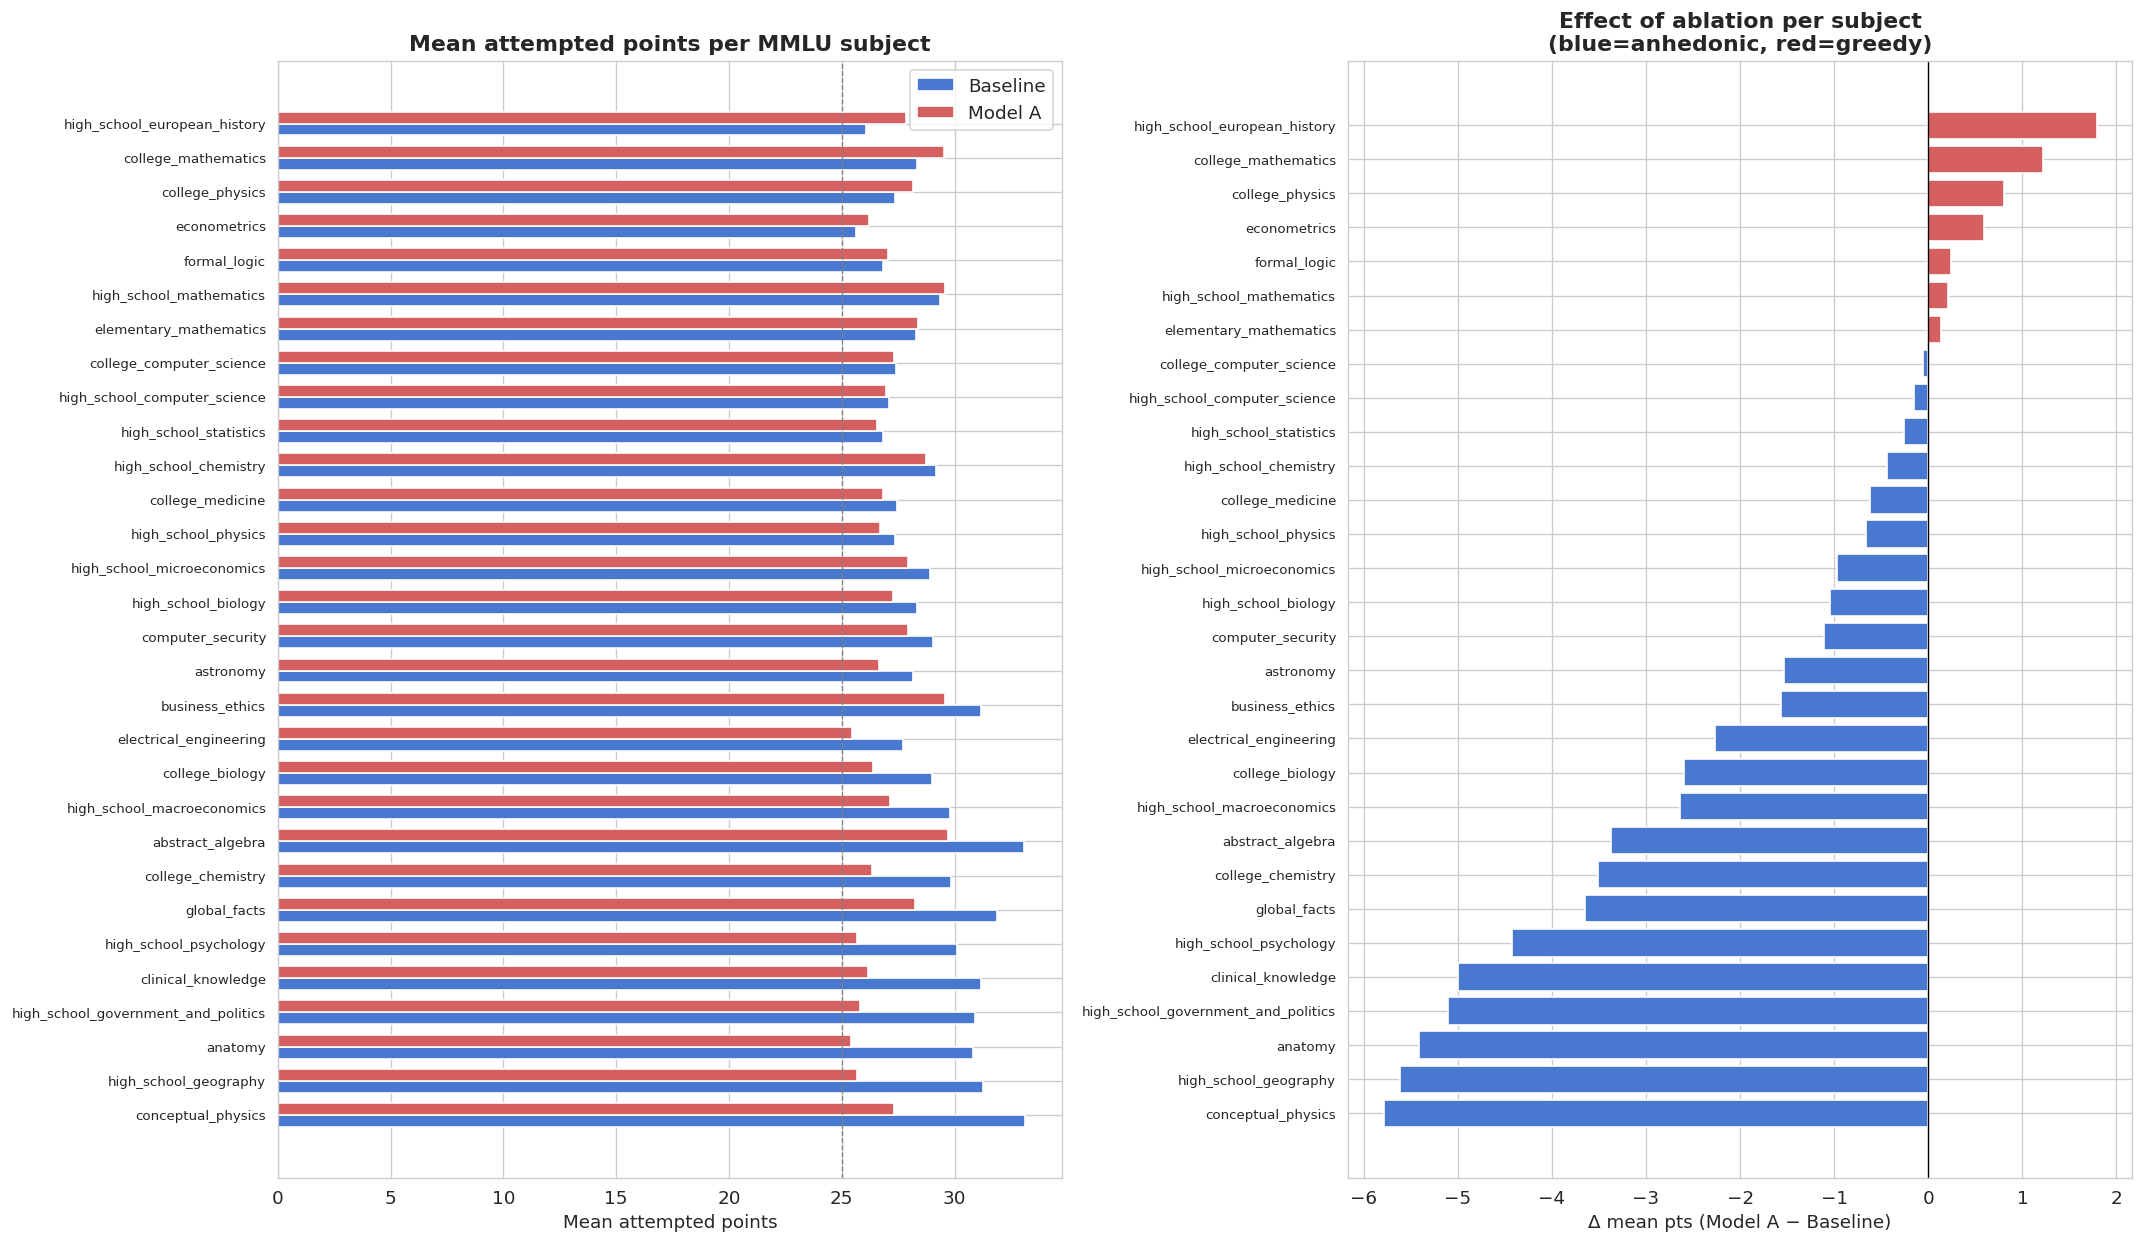


Mean delta across 30 subjects: -1.76 pts
Subjects with anhedonic effect (Δ<0): 23
Subjects with greedy effect   (Δ>0): 7


In [12]:
if mmlu_all.empty:
    print('No MMLU data yet.')
else:
    pivot = mmlu_all.pivot(index='subject', columns='tier', values='mean_att_pts')
    pivot['delta'] = pivot.get('model_A', np.nan) - pivot.get('baseline', np.nan)
    pivot = pivot.sort_values('delta')

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(pivot)*0.35)))

    # Mean pts per subject
    y = np.arange(len(pivot))
    w = 0.35
    axes[0].barh(y-w/2, pivot.get('baseline', 0), w,
                 color=COLORS['baseline'], label='Baseline', edgecolor='white')
    axes[0].barh(y+w/2, pivot.get('model_A', 0), w,
                 color=COLORS['model_A'],  label='Model A',  edgecolor='white')
    axes[0].axvline(25, color='gray', linestyle='--', linewidth=0.8)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(pivot.index, fontsize=8)
    axes[0].set_xlabel('Mean attempted points')
    axes[0].set_title('Mean attempted points per MMLU subject', fontweight='bold')
    axes[0].legend()

    # Delta (model_A - baseline)
    colors_delta = ['#D65F5F' if d > 0 else '#4878CF' for d in pivot['delta']]
    axes[1].barh(y, pivot['delta'], color=colors_delta, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_yticks(y)
    axes[1].set_yticklabels(pivot.index, fontsize=8)
    axes[1].set_xlabel('Δ mean pts (Model A − Baseline)')
    axes[1].set_title('Effect of ablation per subject\n(blue=anhedonic, red=greedy)', fontweight='bold')

    plt.tight_layout()
    plt.savefig('plot_mmlu_per_subject.png', bbox_inches='tight')
    plt.show()

    print(f"\nMean delta across {len(pivot)} subjects: {pivot['delta'].mean():.2f} pts")
    print(f"Subjects with anhedonic effect (Δ<0): {(pivot['delta']<0).sum()}")
    print(f"Subjects with greedy effect   (Δ>0): {(pivot['delta']>0).sum()}")

## 6 — Summary table: all datasets

In [8]:
print(f"{'Dataset':<25} {'Tier':<12} {'Acc%':>6}  {'Mean pts':>9}  {'10pt%':>6}  {'20pt%':>6}  {'30pt%':>6}  {'40pt%':>6}  {'Multi%':>7}")
print('-'*90)

for ds_name, sum_df in [('ASDiv', asdiv_sum), ('Origin', origin_sum)]:
    for _, row in sum_df.iterrows():
        print(f"{ds_name:<25} {row['tier']:<12} "
              f"{row['acc_%']:>6}  {row['mean_att_pts']:>9}  "
              f"{row['10pt_chosen_%']:>6}  {row['20pt_chosen_%']:>6}  "
              f"{row['30pt_chosen_%']:>6}  {row['40pt_chosen_%']:>6}  "
              f"{row['multi_ans_%']:>7}")
    print()

if not mmlu_all.empty:
    mmlu_avg = mmlu_all.groupby('tier')[['acc_%','mean_att_pts',
        '10pt_chosen_%','20pt_chosen_%','30pt_chosen_%',
        '40pt_chosen_%','multi_ans_%']].mean().reset_index()
    print(f'MMLU avg ({len(mmlu_frames)} subjects):')
    for _, row in mmlu_avg.iterrows():
        print(f"{'':25} {row['tier']:<12} "
              f"{row['acc_%']:>6.1f}  {row['mean_att_pts']:>9.1f}  "
              f"{row['10pt_chosen_%']:>6.1f}  {row['20pt_chosen_%']:>6.1f}  "
              f"{row['30pt_chosen_%']:>6.1f}  {row['40pt_chosen_%']:>6.1f}  "
              f"{row['multi_ans_%']:>7.1f}")

print()
print('Note: mean_att_pts > 25 = reward-seeking, < 25 = anhedonic')

Dataset                   Tier           Acc%   Mean pts   10pt%   20pt%   30pt%   40pt%   Multi%
------------------------------------------------------------------------------------------
ASDiv                     baseline      43.77      31.62   14.34   13.58   13.58   58.49     7.99
ASDiv                     model_A       41.33      32.07     6.0    18.0   25.33   50.67    47.92

Origin                    baseline      17.51      37.78     0.0    3.89    14.4   81.71    10.76
Origin                    model_A       84.03      35.21    1.04    8.33   28.12    62.5      0.0

MMLU avg (30 subjects):
                          baseline       50.4       29.0    14.7    20.2    24.9    40.1      1.0
                          model_A        12.7       27.3    18.5    22.4    27.1    32.1      0.0

Note: mean_att_pts > 25 = reward-seeking, < 25 = anhedonic
